<center>
    <img src="https://media.istockphoto.com/id/157713818/photo/xxl-desert-road-thunderstorm.jpg?s=1024x1024&w=is&k=20&c=dnhtOJpBaYxNlI5GeBFlpClp248CgiRtupSMqv9rNNk=" width="700" height="400">
</center>

<center>
    <font size="6">Weather Prediction Model</font>
</center>

## Context (Background)
- Weather prediction is a classical problem in the field of meteorology and data science. Historical weather data contains complex, non-linear, and highly overlapping patterns. Furthermore, extreme weather events (like Snow or Fog) are rare occurrences compared to regular weather conditions (like Sun or Rain), leading to highly imbalanced datasets. Understanding and modeling these conditions is critical for building robust predictive systems.

## Objective
- The primary objective of this project is to perform comprehensive Exploratory Data Analysis (EDA) on a meteorological dataset and build a Machine Learning classification model to accurately predict the daily weather condition (weather).

### Specific goals include:

- Identifying feature relationships and distributions using visual analysis (Heatmaps, Boxplots).

- Handling severe class imbalance using algorithmic techniques (e.g., class_weight='balanced').

- Comparing the performance of distance-based (SVM) and tree-based (Decision Tree) algorithms to determine the best approach for this specific data structure.

### Executive Summary
- **Data Exploration:** The dataset contains 1,461 records with features like precipitation, wind speed, and temperature. The target variable (weather) was heavily imbalanced, dominated by 'Rain' and 'Sun', with minority classes like 'Snow' and 'Drizzle' having very few records.

- **Model 1 -** Support Vector Machine (SVM): A scaled SVM with an RBF kernel was deployed to handle the non-linear boundaries. While it achieved an accuracy of 61.09%, it heavily penalized its precision to maximize the recall for rare classes, leading to over-prediction of 'Fog' and 'Snow'.

- **Model 2 -** Decision Tree Classifier: Shifting to a tree-based algorithm (max_depth=5) significantly improved the overall accuracy to 73.04%. The model successfully created stable logical splits for majority classes. However, due to the extreme lack of data and feature overlap, it completely dropped the highly minority class ('Drizzle').

- **Conclusion:** The project successfully demonstrates that for highly imbalanced and overlapping tabular data, tree-based models generally outperform distance-based models. To push the accuracy beyond 80% in the future, data-level balancing techniques like SMOTE (Synthetic Minority Over-sampling Technique) would be required to generate synthetic records for the rare classes.

## Importing necessary libraries..

In [1]:
# libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# library to split data
from sklearn.model_selection import train_test_split

# library to preprocessing our data like scalling and encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# library to get different metric score
from sklearn.metrics import accuracy_score, classification_report

# library to scalled data
from sklearn.preprocessing import StandardScaler

## Loading the dataset..

In [2]:
# Mounting Google drive to access the dataset
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/Datasets/seattle-weather.csv")

## Data Overview..

- View the first and last 5 rows of the dataset :-

In [4]:
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [5]:
data.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun
1460,2015-12-31,0.0,5.6,-2.1,3.5,sun


- The dataset contains information about different weather conditions.

## Understant the shape of the dataset..

In [6]:
data.shape

(1461, 6)

- The dataset has 1,461 rows and 6 columns.

## Check the data types of the columns for the dataset..

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


- There are a total of 6 columns and 1461 rows in the dataset.

- We have two object variables - date and weather (categorical target).

- All other 4 variables are continuous numerical features.

- The dataset contains zero missing values, so no dropping or imputation is required.

## Checking for duplicate values..

In [8]:
data.duplicated().sum()

np.int64(0)

- There are no duplicate values in the dataset.

## Checking for missing values..

In [9]:
data.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


- There are no missing values in the dataset.

## Statistical Summary..

In [10]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
precipitation,1461.0,3.029432,6.680194,0.0,0.0,0.0,2.8,55.9
temp_max,1461.0,16.439083,7.349758,-1.6,10.6,15.6,22.2,35.6
temp_min,1461.0,8.234771,5.023004,-7.1,4.4,8.3,12.2,18.3
wind,1461.0,3.241136,1.437825,0.4,2.2,3.0,4.0,9.5


- **Precipitation Outliers:** Median is 0.0 but max is 55.9, indicating highly right-skewed data with extreme rainy/snowy days.

- **Normal Wind Distribution:** Mean (3.24) and Median (3.0) are almost equal, showing a perfect bell-curve shape without crazy extremes.

- **Seasonal Temperature Variations:** A wide temperature range (-7.1°C to 35.6°C) confirms clear and distinct weather seasons.

- **Scaling is Compulsory:** The huge difference in numeric ranges (e.g., wind vs. precipitation) means we must use StandardScaler before applying distance-based models like SVM or KNN.

In [11]:
# Printing number of count of each unique value in weather variable
data["weather"].value_counts()

,count
weather,
rain,641
sun,640
fog,101
drizzle,53
snow,26


In [12]:
data["weather"] = data.weather.astype("category")

In [13]:
data.groupby(["weather"]).count()

/tmp/ipykernel_841/95889136.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["weather"]).count()


,date,precipitation,temp_max,temp_min,wind
weather,,,,,
drizzle,53,53,53,53,53
fog,101,101,101,101,101
rain,641,641,641,641,641
snow,26,26,26,26,26
sun,640,640,640,640,640


- Weather distribution among majority (Rain, Sun) and minority (Fog, Drizzle, Snow) is almost 7:1. The model will better predict Rain and Sun.

## Dropped unnecessary columns..

In [14]:
# Dropping the "date" column
clean_data = data.drop(["date"], axis = 1)

In [15]:
clean_data.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain


In [16]:
clean_data.shape

(1461, 5)

- The dataset has 1,461 rows and 5 columns.

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>

### **Note:** The EDA section has been covered multiple times in the previous case studies. In this case study, we will mainly focus on the model building aspects. We will only be looking at the key observations from EDA.

### Univariate analysis..

In [17]:
def histogram_boxplot(data, feature, figsize=(15,10), kde = False, bins=None):
  """
  Boxplot and histplot combined

  data: dataframe
  feature: dataframe column
  figsize: size of figure (default (15,10))
  kde: whether to show the density curve (default False)
  bins: number of bins for histgrom (default None)
  """
  f2, (ax_box2, ax_hist2) = plt.subplots(
      nrows = 2, # Number of rows of the subplot grid = 2
      sharex = True, # x-axis will be shared among all subplots
      gridspec_kw = {"height_ratios": (0.25, 0.75)},
      figsize = figsize,
  ) # Creating the 2 subplots
  sns.boxplot(
      data = data, x=feature, ax=ax_box2, showmeans=True, color = "teal"
  ) # Boxplot will be created and a tringle will indicate the mean value of the column
  sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color = "orange"
  ) if bins else sns.histplot(
      data=data, x=feature, kde=kde, ax=ax_hist2, color = "orange"
  ) # For histgrom
  ax_hist2.axvline(
      data[feature].mean(), color="green", linestyle="--"
  ) # Add mean to the histogram
  ax_hist2.axvline(
      data[feature].median(),color="black", linestyle="-"
  ) # Add median to the histgrom

In [18]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### Observation on precipitation :-

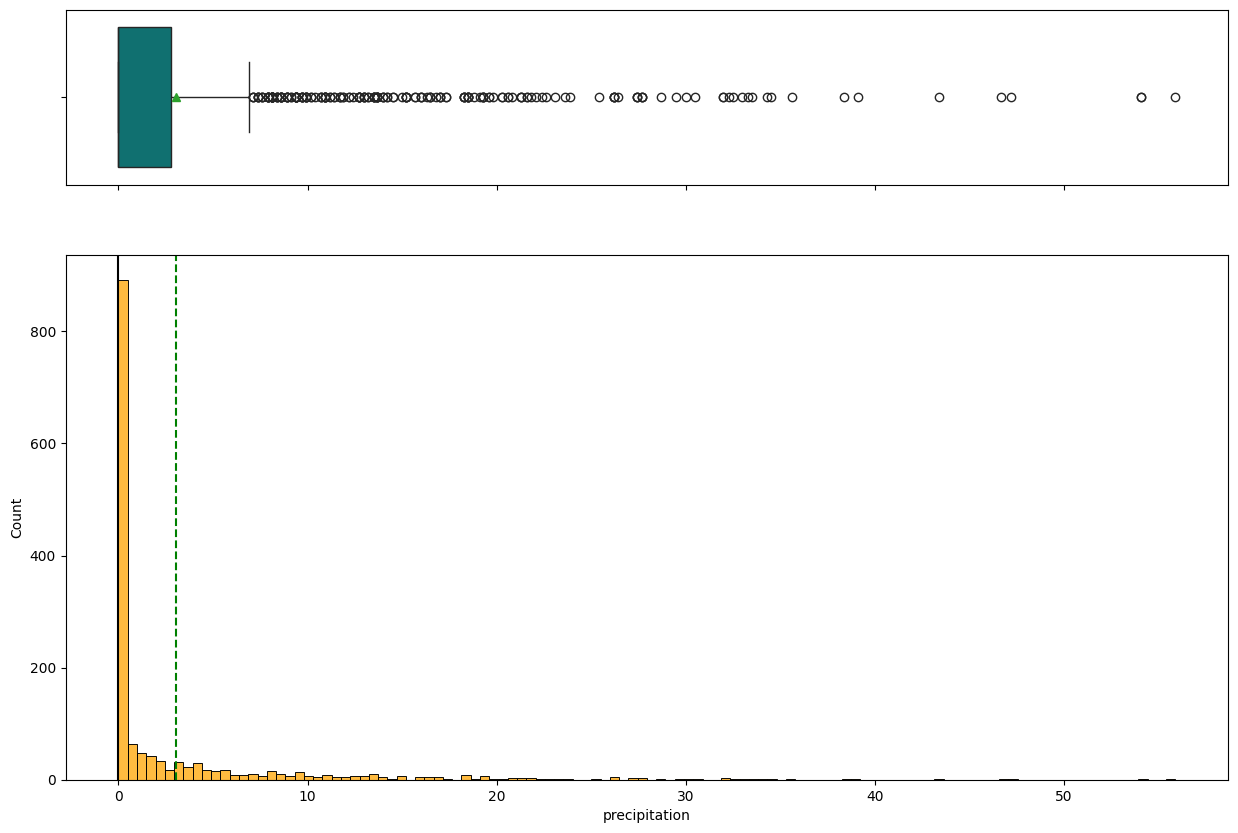

In [19]:
histogram_boxplot(clean_data, "precipitation")

- **Mostly Dry Days:** For most of the year, there is absolutely zero rain or snow.

- **Extreme Outliers:** There are a few days with very heavy rainfall (values reaching up to 55.9).

- **Right-Skewed Data:** The data is heavily right-skewed because the mean is much higher than the median (which is 0).

### Observation on temp_max :-

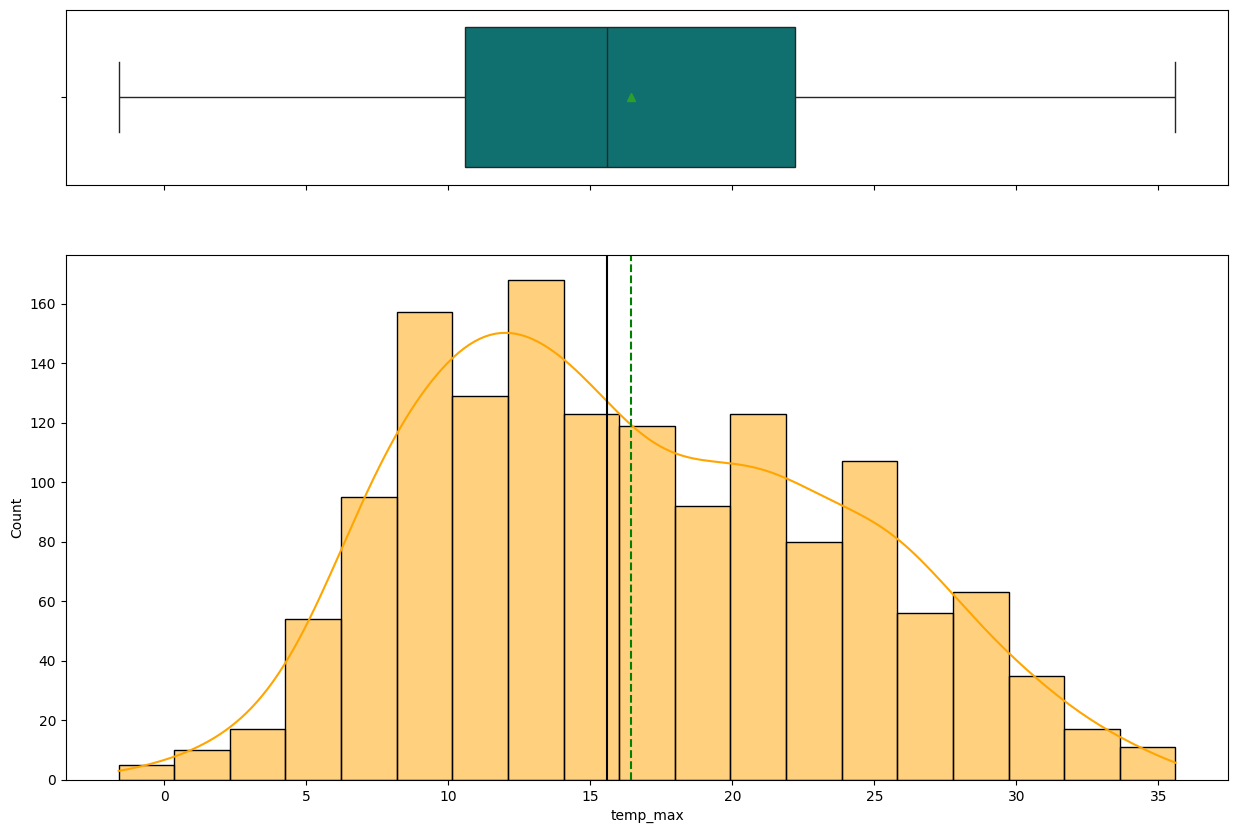

In [20]:
histogram_boxplot(clean_data, "temp_max", kde = True)

- **No Outliers:** The boxplot shows absolutely no data points (circles) outside the whiskers. This means there are no extreme or abnormal temperature entries in our dataset.

- **Slightly Right-Skewed:** The Mean (green dashed line) is slightly higher than the Median (black solid line), indicating a very minor right skew, but it is well-balanced overall.

- **Bimodal Spread (Seasonality):** The histogram is not a single perfect bell curve; it shows a wide spread with a wavy top (one peak around 10-15°C and another smaller hump around 20-25°C). This logically perfectly represents distinct weather seasons (colder months vs. warmer months).

### Observation on temp_min :-

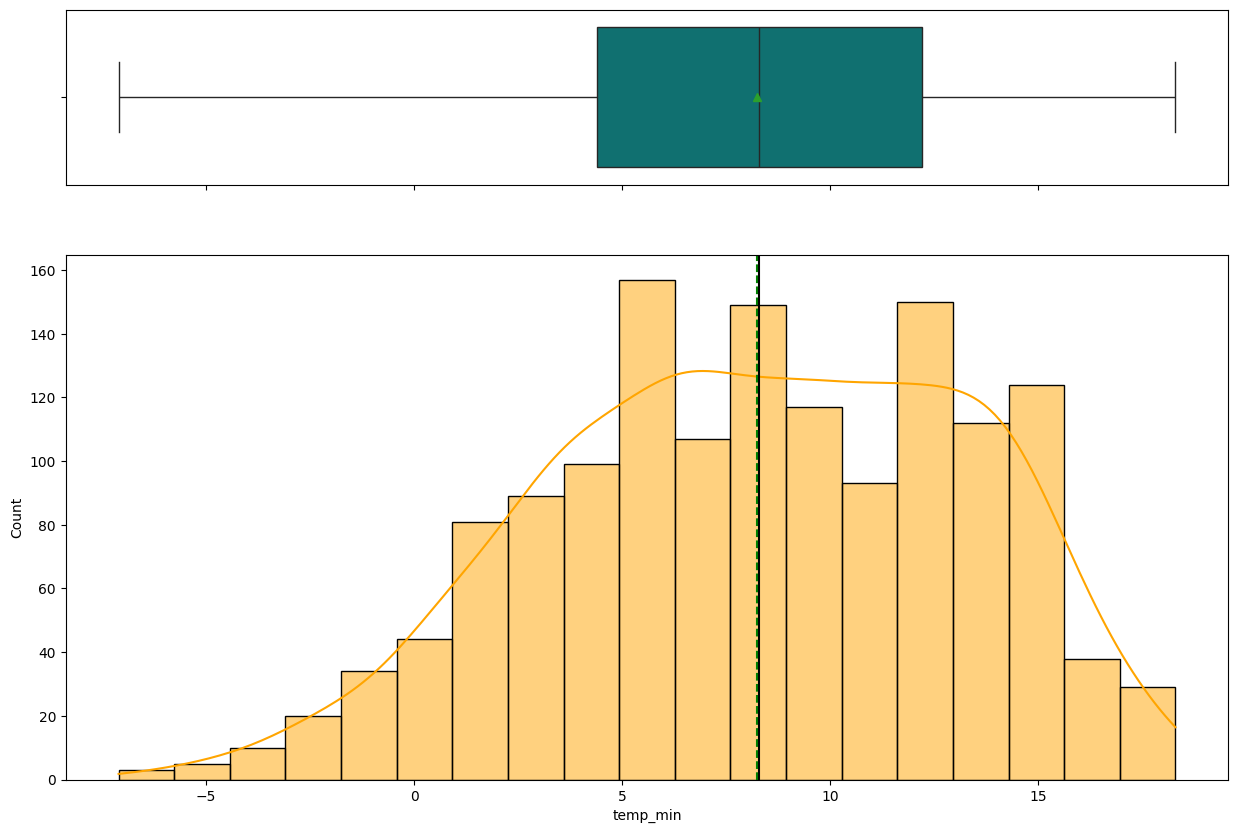

In [21]:
histogram_boxplot(clean_data, "temp_min", kde = True)

- **Perfectly Symmetrical:** The Mean (green dashed line) and the Median (black solid line) are overlapping almost perfectly. This indicates that the data has zero skewness and is perfectly balanced on both sides.

- **No Outliers:** Just like the maximum temperature, the boxplot shows absolutely zero outliers. All minimum temperature records fall within the expected seasonal ranges.

- **Broad and Flat Spread:** The histogram and curve do not have one single sharp peak (bell curve). Instead, it has a wide, relatively flat top spanning from 0°C to 15°C. This perfectly captures the steady variation of nighttime temperatures across different seasons throughout the year.

### Observation on wind :-

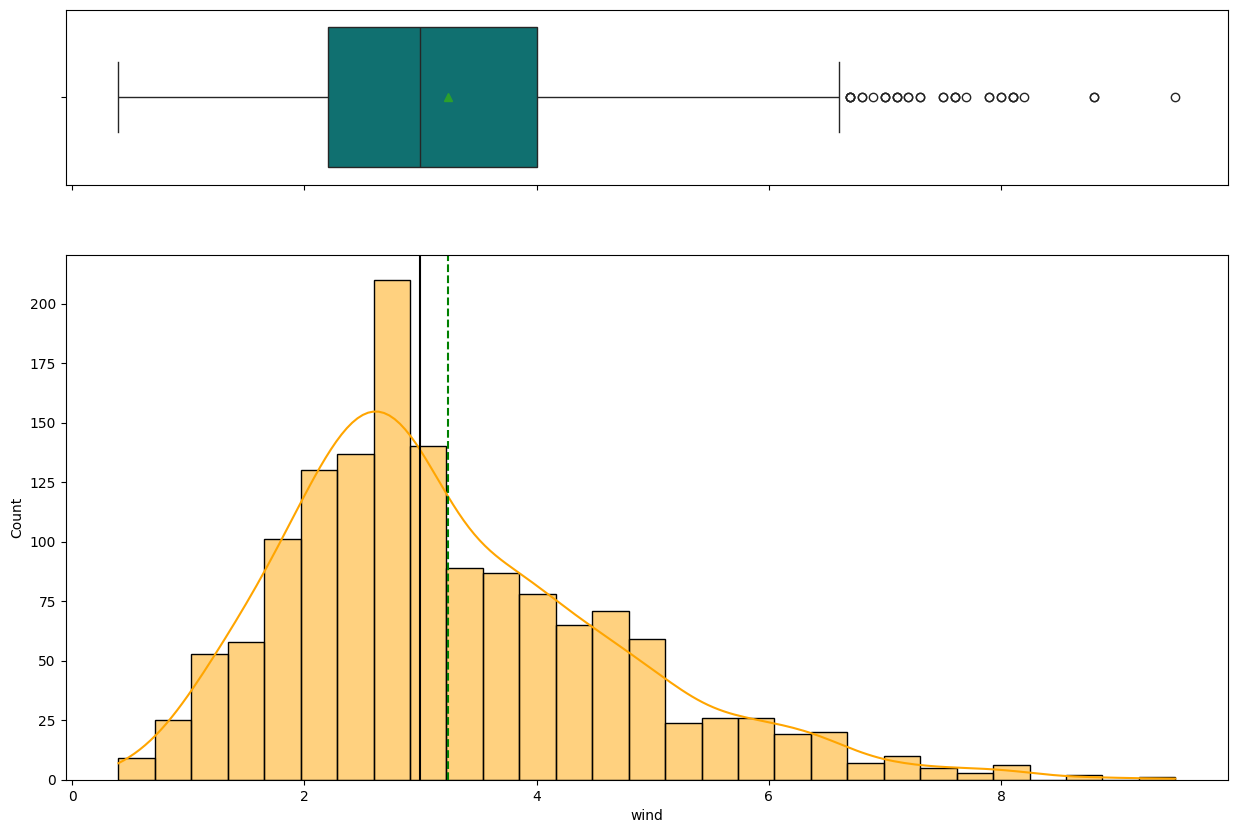

In [22]:
histogram_boxplot(clean_data, "wind", kde = True)

- **Mildly Right-Skewed:** The Mean (green dashed line) is slightly to the right of the Median (black solid line). This shows a slight positive skewness in the wind data.

- **Upper-End Outliers:** Unlike the temperature columns, the boxplot here shows several outliers (circles) on the right side (values above 6). These represent occasionally very windy/stormy days.

- **Concentrated Normal Days:** The highest peak of the histogram shows that for the vast majority of the days, the wind speed is relatively calm, staying compactly between the range of 2.0 to 4.0.

### Observation on weather :-

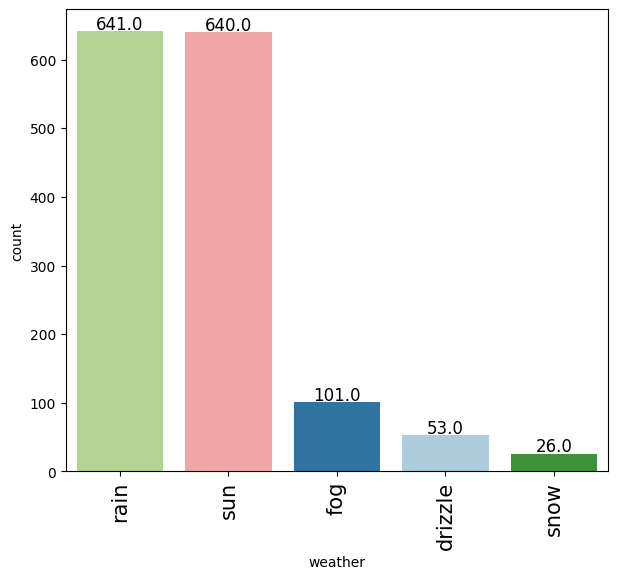

In [23]:
labeled_barplot(clean_data, "weather")

- **Severe Class Imbalance:** The chart visually confirms a massive class imbalance. The dataset is heavily dominated by 'Rain' (641) and 'Sun' (640).

- **Equal Majority:** Interestingly, the top two majority classes ('Rain' and 'Sun') are almost perfectly equal in number, forming an almost 50-50 split between themselves.

- **Minority Classes:** 'Fog' (101), 'Drizzle' (53), and 'Snow' (26) represent the extreme minority.

- **Modeling Action Required:** This chart proves that we MUST use techniques like class_weight='balanced' when building our Machine Learning models, otherwise, the model will simply ignore the rare weather events.

### Bivariate analysis..

### Heatmap :-

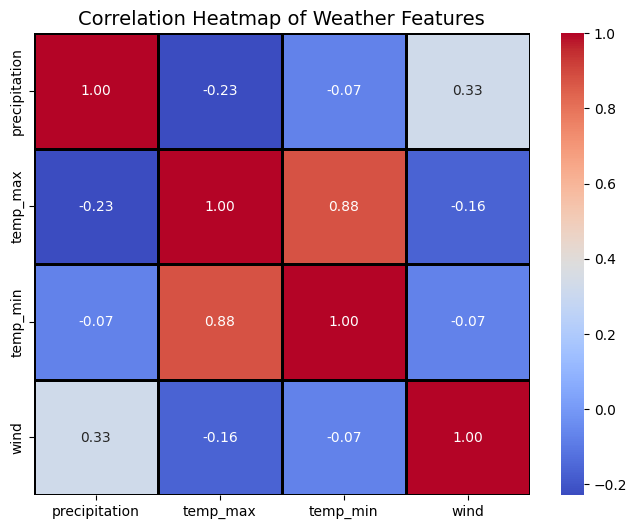

In [24]:
plt.figure(figsize = (8,6))
numerical_cols = clean_data[["precipitation", "temp_max", "temp_min", "wind"]]
sns.heatmap(numerical_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidth=1, linecolor="black")
plt.title("Correlation Heatmap of Weather Features", fontsize=14)
plt.show()

- **High Multicollinearity (Strong Friendship):** The strongest relationship in the dataset is between temp_max and temp_min with a very high positive correlation score of 0.88. Practically, this makes sense—days with a higher maximum temperature generally also have a higher minimum temperature.

- **Moderate Positive Correlation:** precipitation and wind show a moderate positive correlation of 0.33. This logically indicates that rainy or snowy days often come with higher wind speeds (e.g., storms).

- **Weak Negative Correlation (Slight Enmity):** precipitation and temp_max have a slight negative correlation of -0.23. This means that as the maximum temperature goes up (hotter days), the chances of precipitation slightly go down.

- **Independent Features:** Other pairs (like wind and temp_min) have scores very close to 0 (e.g., -0.07), meaning they do not affect each other and act independently.

### Boxplot :-

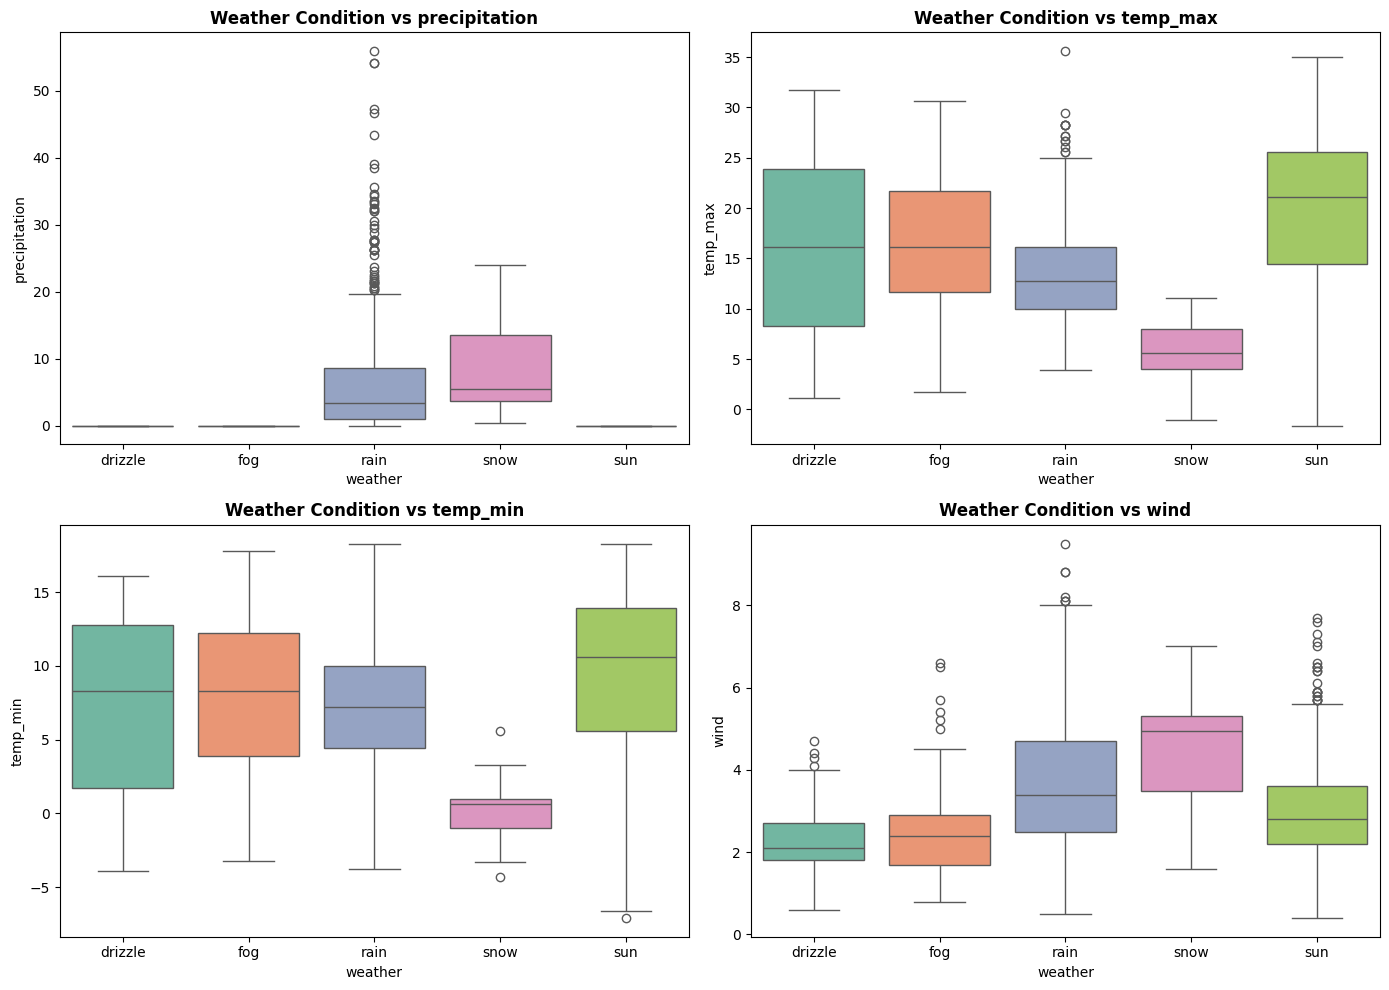

In [25]:
features = ["precipitation", "temp_max", "temp_min", "wind"]

plt.figure(figsize = (14,10))

for i, feature in enumerate(features):
  plt.subplot(2,2,i+1)
  sns.boxplot(x="weather", y=feature, data=clean_data, hue="weather", palette="Set2", legend=False)
  plt.title(f"Weather Condition vs {feature}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

- **Precipitation is a Key Differentiator:** 'Sun', 'Fog', and 'Drizzle' record almost zero precipitation. In contrast, 'Rain' shows extreme upper outliers (heavy rainfall), and 'Snow' shows a consistent, strictly positive precipitation range.

- **Clear Temperature Boundaries:** As logically expected, 'Sun' has the highest median for both temp_max and temp_min. 'Snow' has the lowest temperatures, with its median temp_min hovering around 0°C. This clear separation will make it very easy for the model to classify these two classes.

- **Wind Indicates Stormy Weather:** 'Rain' and 'Snow' generally experience higher wind speeds compared to calmer days like 'Sun' or 'Fog'. The extreme wind outliers in 'Rain' point towards occasional severe storms.

- **High Separability:** Every weather condition shows a unique behavior across these 4 features. This proves that our dataset is highly logical and excellent for Machine Learning classification.

## Data Preprocessing..

### Encoding :-

In [29]:
# Initialization of LabelEncoder
le = LabelEncoder()

clean_data["weather"] = le.fit_transform(clean_data["weather"])
print("Weather successfully converted to numbers!")

Weather successfully converted to numbers!


- **In-Place Transformation:** The categorical target column weather has been successfully overwritten with numerical values (e.g., 0, 1, 2, 3, 4).

- **Machine-Readable Format:** By removing the text-based strings, the dataset is now fully numerical and 100% compatible with mathematical and distance-based algorithms like SVM.

- **Efficient Memory Usage:** Updating the existing clean_data DataFrame directly prevents data fragmentation and saves memory by not creating redundant target arrays.

In [30]:
# Checking our data
clean_data.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,0
1,10.9,10.6,2.8,4.5,2
2,0.8,11.7,7.2,2.3,2
3,20.3,12.2,5.6,4.7,2
4,1.3,8.9,2.8,6.1,2


### Splitting :-

In [33]:
X = clean_data.drop(columns=["weather"])
y = clean_data["weather"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state = 42)

print("Data Successfully Split!")
print("-"*40)
print(f"Total rows in original data: {clean_data.shape[0]}")
print(f"Rows for Traning (80%): {X_train.shape[0]}")
print(f"Rows for Testing (20%): {X_test.shape[0]}")

Data Successfully Split!
----------------------------------------
Total rows in original data: 1461
Rows for Traning (80%): 1168
Rows for Testing (20%): 293


#### Dataset Division: The dataset of 1,461 records was successfully split into training and testing sets using the standard 80:20 ratio.
- **Training Set:** A substantial portion of the data, comprising 1,168 rows, has been allocated for the machine learning models to learn patterns and relationships.

- **Testing Set:** A separate, unseen set of 293 rows has been securely kept aside. This will act as the "final exam" to evaluate the true accuracy and generalizability of the trained models on new, real-world customer data.

### Feature Scalling :-

In [34]:
# Initialize the Standard Scaler
scaler = StandardScaler()

# Fit and transform the traning data only
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data (No fitting here to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

print("Feature Scalling Complete!\n")
print("First row of scaled traning data:")
print(X_train_scaled[0])

Feature Scalling Complete!

First row of scaled traning data:
[-0.45562998 -1.48337156 -2.29332143  1.71531431]


- **StandardScaler:** This is the most standard method of statistical scaling. It sets the mean of the data to 0 and the standard deviation to 1.

- **fit_transform (for Train):** The model calculates the mean and variance of X_train (fit) and scales them (transform).

- **transform (for Test):** We don't re-fit here. The model applies the same old X_train calculations to X_test to avoid cheating!

# <a name='link2'>Support Vector Machine (SVM) Model :-</a>

### SVM Model Initialization & Traning..

In [35]:
# library to build model for prediction
from sklearn.svm import SVC

# SVM model initialization
svm_model = SVC(kernel = "rbf", class_weight = "balanced", random_state=42)

print("Training Support Vector Machine (SVM) Model...")
svm_model.fit(X_train_scaled, y_train)

Training Support Vector Machine (SVM) Model...


SVC(class_weight='balanced', random_state=42)

### Model Evalution :-

In [36]:
# Prediction of testing data
y_pred_svm = svm_model.predict(X_test_scaled)

In [37]:
# Matrics calculation
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("="*40)
print("SUPPORT VECTOR MACHINE (SVM) RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_svm * 100:.2f}%")

SUPPORT VECTOR MACHINE (SVM) RESULTS
Accuracy  : 61.09%


In [38]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_svm))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.10      0.22      0.14         9
           1       0.23      0.72      0.35        25
           2       0.92      0.65      0.76       120
           3       0.29      0.62      0.40         8
           4       0.83      0.58      0.68       131

    accuracy                           0.61       293
   macro avg       0.47      0.56      0.47       293
weighted avg       0.78      0.61      0.66       293



- **The Impact of 'Balanced' Weights:** The overall accuracy is 61.09%, which seems low, but it accurately reflects the penalty imposed by class_weight='balanced'. The SVM deliberately sacrificed overall accuracy on majority classes to focus aggressively on the rare weather events.

- **Minority Classes (Fog & Snow) - High Recall, Low Precision:** For Class 1 (Fog) and Class 3 (Snow), the Recall is highly impressive (0.72 and 0.62). The model successfully catches most of the actual Fog and Snow days. However, the Precision is extremely low (0.23 and 0.29), meaning it over-predicts these conditions, frequently misclassifying regular cold/windy days as Fog or Snow.

- **Majority Classes (Rain & Sun) - High Precision, Lower Recall:** Class 2 (Rain) and Class 4 (Sun) have excellent Precision (0.92 and 0.83). When the model predicts Rain or Sun, it is almost always correct. However, their Recall has dropped (0.65 and 0.58) because the model is too afraid to guess these classes, fearing it might miss a rare event.

- **The 'Drizzle' Dilemma:** Class 0 (Drizzle) performed the poorest (F1-score: 0.14). Its features likely overlap almost entirely with 'Rain' or 'Fog' in the multidimensional space, making it nearly impossible for the SVM's RBF kernel to draw a clear decision boundary.

# <a name='link2'> Decision Tree Model :-</a>

### Decision Tree model initialization & Traning

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

# Decision tree model initialization
dt_model = DecisionTreeClassifier(random_state = 42)

print("Training Decision Tree Model..")
dt_model.fit(X_train_scaled, y_train)

Training Decision Tree Model..


DecisionTreeClassifier(random_state=42)

### Model Evalution :-

In [44]:
# Prediction of testing data
y_pred_dt = dt_model.predict(X_test_scaled)

In [45]:
# Metrics calculation
accuracy_dt = accuracy_score(y_test, y_pred_dt)


print("\n" + "="*40)
print("DECISION TREE RESULTS")
print("="*40)
print(f"Accuracy  : {accuracy_dt * 100:.2f}%")


DECISION TREE RESULTS
Accuracy  : 73.04%


In [46]:
print("Detailed Classification Report:\n")
print(classification_report(y_test, y_pred_dt))
print("=" * 55)

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.23      0.20      0.21        25
           2       0.90      0.88      0.89       120
           3       0.36      0.50      0.42         8
           4       0.78      0.76      0.77       131

    accuracy                           0.73       293
   macro avg       0.45      0.47      0.46       293
weighted avg       0.74      0.73      0.74       293



- **Significant Accuracy Leap:** Switching from SVM to a Decision Tree improved the overall accuracy by ~12% (from 61% to 73%). The tree-based algorithm was much better at handling the non-linear, overlapping nature of the weather data.

- **Mastery over Majority Classes:** The model performed exceptionally well on Class 2 (Rain) and Class 4 (Sun). Their F1-scores jumped to 0.89 and 0.77 respectively. Unlike the SVM, the Decision Tree did not blindly sacrifice these majority classes.

- **The 'Drizzle' Collapse (Class 0):** The model completely failed to identify Class 0 (Precision, Recall, F1 are all 0.00). This indicates that the features for 'Drizzle' overlap entirely with 'Rain' or 'Fog'. The tree's rules (limited by max_depth=5) simply grouped 'Drizzle' into the larger 'Rain' category.

- **Struggle with Extreme Minorities:** While Class 3 (Snow) maintained a decent Recall of 0.50, Class 1 (Fog) saw a massive drop in Recall (from 0.72 in SVM to 0.20 here). The tree found it mathematically inefficient to create dedicated branches for such few 'Fog' data points without risking overfitting.

### Why We Should Not Remove These Outliers :-
- **They Are Not Data Errors (Real-World Events):** In most datasets, outliers are accidental typing mistakes (like age = 200). However, in weather data, a precipitation of 55.9 or a wind speed of 9.5 is not an error. These represent real-world storms or heavy rainfall days. If we remove them, our model will assume that heavy rain never happens in the real world!

- **Signatures of Minority Classes:** We already have very few records for 'Snow' and 'Fog' (only 26 and 101 rows, respectively). These extreme outlier values are the exact signatures used to identify such extreme weather conditions. Removing them would mean essentially blinding our model to these rare events.

- **Data Loss:** If we drop the outliers, we will lose around 10-15% of our rows. In a small dataset of just 1,461 rows, we simply cannot afford to waste that much data.